Exercicio 1

Estimativas Monte Carlo (ln(1+x)):
N=   100  ->  I_MC = 0.367051   Erro = 0.019244
N=  1000  ->  I_MC = 0.390832   Erro = 0.004538
N= 10000  ->  I_MC = 0.383880   Erro = 0.002414
N=100000  ->  I_MC = 0.385630   Erro = 0.000664


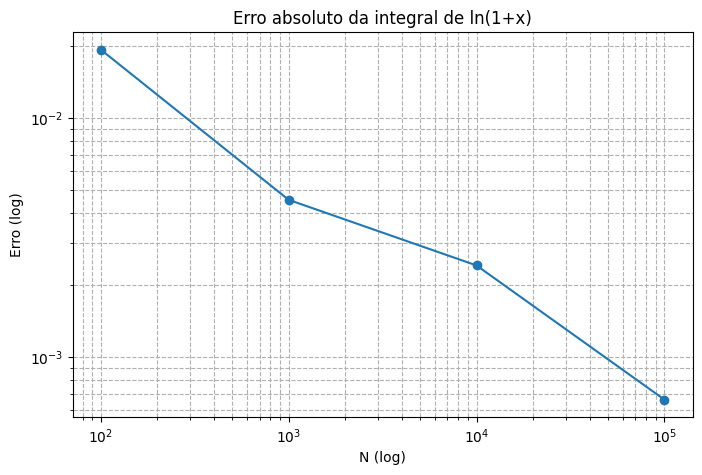

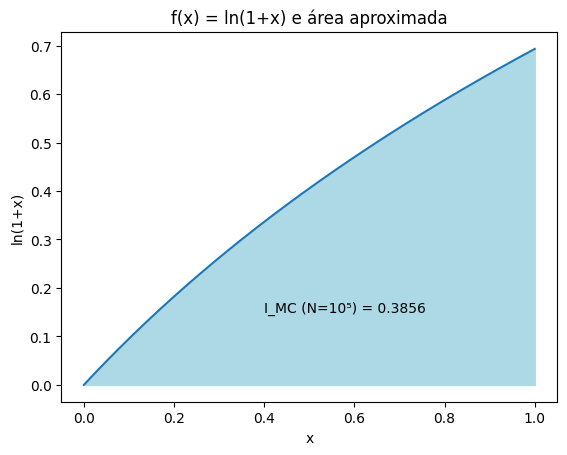

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Função correta: ln(1+x)
def f(x):
    return np.log(1 + x)

# Valor exato da integral: 2 ln 2 - 1
I_exato = 2*np.log(2) - 1

# N's
Ns = [10**2, 10**3, 10**4, 10**5]

estimativas = []
erros = []

# (a) e (b)
for N in Ns:
    x = np.random.uniform(0, 1, N)
    I_MC = np.mean(f(x))
    estimativas.append(I_MC)
    erros.append(abs(I_MC - I_exato))

print("Estimativas Monte Carlo (ln(1+x)):")
for N, est, err in zip(Ns, estimativas, erros):
    print(f"N={N:>6}  ->  I_MC = {est:.6f}   Erro = {err:.6f}")

# (c) Erro absoluto
plt.figure(figsize=(8,5))
plt.loglog(Ns, erros, marker='o')
plt.xlabel("N (log)")
plt.ylabel("Erro (log)")
plt.title("Erro absoluto da integral de ln(1+x)")
plt.grid(True, which="both", linestyle="--")
plt.show()

# Plot da função ln(1+x)
x_plot = np.linspace(0, 1, 500)
plt.plot(x_plot, f(x_plot))
plt.fill_between(x_plot, f(x_plot), color='lightblue')
plt.text(0.4, 0.15, f'I_MC (N=10⁵) = {estimativas[-1]:.4f}')
plt.xlabel("x")
plt.ylabel("ln(1+x)")
plt.title("f(x) = ln(1+x) e área aproximada")
plt.show()

Exercicio 2

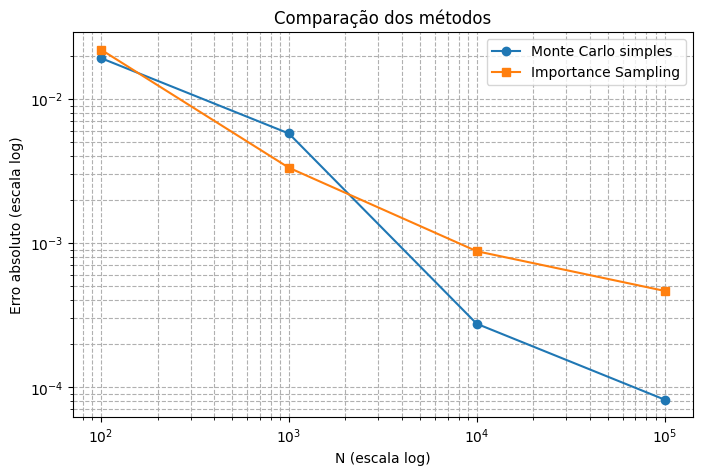


Resultados:
N=   100  MC=0.519221 (erro=0.019221)   IS=0.477992 (erro=0.022008)
N=  1000  MC=0.505758 (erro=0.005758)   IS=0.503332 (erro=0.003332)
N= 10000  MC=0.499725 (erro=0.000275)   IS=0.499123 (erro=0.000877)
N=100000  MC=0.499918 (erro=0.000082)   IS=0.499535 (erro=0.000465)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Função alvo: f(x) = 1/(1+x)^2
def f(x):
    return 1 / (1 + x)**2

# Valor exato da integral
I_exato = 0.5

# N's para comparar
Ns = [10**2, 10**3, 10**4, 10**5]

MC_est = []
IS_est = []
erro_MC = []
erro_IS = []

# (a) Monte Carlo simples
for N in Ns:
    x = np.random.uniform(0, 1, N)
    I_MC = np.mean(f(x))
    MC_est.append(I_MC)
    erro_MC.append(abs(I_MC - I_exato))

    # (b) escolha de p(x) = 1 / ((1+x)*ln2)
    # (c) Importance Sampling via inversão: X = 2^U - 1
    u = np.random.rand(N)
    x_IS = 2**u - 1

    # Estimador: f(x)/p(x) = ln(2)/(1+x)
    w = np.log(2) / (1 + x_IS)
    I_IS = np.mean(w)

    IS_est.append(I_IS)
    erro_IS.append(abs(I_IS - I_exato))

# (d) Comparação gráfica dos erros
plt.figure(figsize=(8,5))
plt.loglog(Ns, erro_MC, marker='o', label="Monte Carlo simples")
plt.loglog(Ns, erro_IS, marker='s', label="Importance Sampling")
plt.xlabel("N (escala log)")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Comparação dos métodos")
plt.grid(True, which="both", linestyle="--")
plt.legend()
plt.show()

# (e) impressão dos valores
print("\nResultados:")
for N, mc, isv, e1, e2 in zip(Ns, MC_est, IS_est, erro_MC, erro_IS):
    print(f"N={N:6}  MC={mc:.6f} (erro={e1:.6f})   IS={isv:.6f} (erro={e2:.6f})")

exercicio 3

Taxa de aceitação (AR): 0.3325


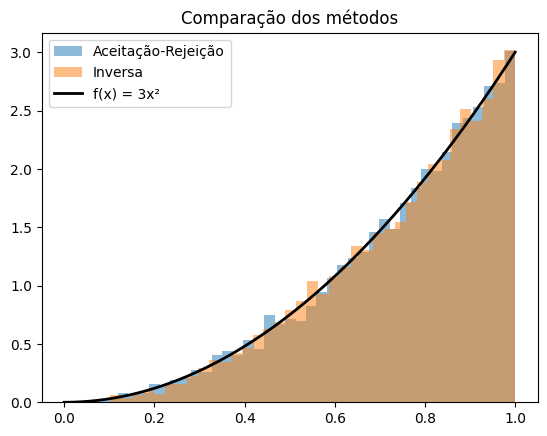

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# PDF alvo f(x) = 3 x^2
def f(x):
    return 3 * x**2

# (a) Aceitação-Rejeição
def amostras_AR(N):
    samples = []
    M = 3  # máximo da PDF
    total = 0

    while len(samples) < N:
        x = np.random.rand()        # proposta uniforme
        u = np.random.rand()        # para teste
        total += 1
        if u <= f(x) / M:
            samples.append(x)

    return np.array(samples), len(samples) / total  # amostras e taxa de aceitação

# (c) Método da Inversa
def amostras_inversa(N):
    u = np.random.rand(N)
    return u**(1/3)

# (d) Comparação + Eficiência
N = 10000

# AR
samples_AR, taxa_aceitacao = amostras_AR(N)

# Inversa
samples_INV = amostras_inversa(N)

# (b) Taxa de aceitação
print(f"Taxa de aceitação (AR): {taxa_aceitacao:.4f}")

# Histogramas comparativos
plt.hist(samples_AR, bins=40, density=True, alpha=0.5, label="Aceitação-Rejeição")
plt.hist(samples_INV, bins=40, density=True, alpha=0.5, label="Inversa")
x = np.linspace(0,1,500)
plt.plot(x, f(x), 'k-', linewidth=2, label="f(x) = 3x²")
plt.legend()
plt.title("Comparação dos métodos")
plt.show()

exercicio 4

In [5]:
import numpy as np

N = 200000  # número de simulações

# Representação do baralho
deck = ["A"]*12 + ["B"]*12 + ["C"]*12 + ["D"]*12

# (a) Sem reposição
count_no_replacement = 0

for _ in range(N):
    draw = np.random.choice(deck, size=7, replace=False)
    if ("B" in draw) and ("D" in draw):
        count_no_replacement += 1

P_no_replacement = count_no_replacement / N


# (b) Com reposição
count_with_replacement = 0

types = ["A", "B", "C", "D"]

for _ in range(N):
    draw = np.random.choice(types, size=7, replace=True)
    if ("B" in draw) and ("D" in draw):
        count_with_replacement += 1

P_with_replacement = count_with_replacement / N


# Resultados
print(f"(a) Prob. sem reposição: {P_no_replacement:.5f}")
print(f"(b) Prob. com reposição: {P_with_replacement:.5f}")

(a) Prob. sem reposição: 0.77702
(b) Prob. com reposição: 0.74089


exercicio 5

In [6]:
import numpy as np

N = 200000  # número de simulações

# (a) Simulação Monte Carlo
count = 0

for _ in range(N):
    d1 = np.random.randint(1, 7)
    d2 = np.random.randint(1, 7)
    if d1 + d2 > 9:
        count += 1

P_MC = count / N

# (b) Valor teórico
P_teorico = 1/6

print(f"(a) Probabilidade estimada (MC): {P_MC:.6f}")
print(f"(b) Valor teórico:             {P_teorico:.6f}")
print(f"(c) Erro absoluto:             {abs(P_MC - P_teorico):.6f}")

(a) Probabilidade estimada (MC): 0.167130
(b) Valor teórico:             0.166667
(c) Erro absoluto:             0.000463
